In [1]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device {device}")

Using device cuda


In [2]:
#!pip install diffusers

In [3]:
from diffusers import StableDiffusionPipeline

/home/ciabd01/anaconda3/envs/yolo_clase/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#!pip install transformers

In [5]:
pipe = StableDiffusionPipeline.from_pretrained(
"stable-diffusion-v1-5/stable-diffusion-v1-5",
torch_dtype=torch.float16,
).to(device)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  9.69it/s]


100%|██████████| 50/50 [00:05<00:00,  8.66it/s]


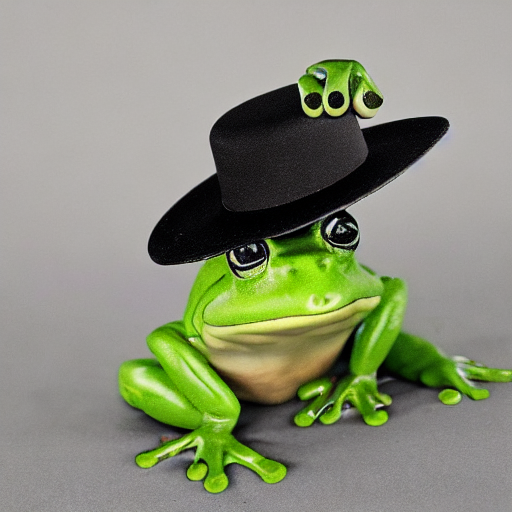

In [45]:
prompt = "frog carrying a hat"
pipe(prompt).images[0]



In [21]:
from transformers import pipeline
# Clasificación de sentimiento
classifier = pipeline("text-classification", device=device)
classifier("This movie is disgustingly good!")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 14732.76it/s]


[{'label': 'POSITIVE', 'score': 0.9998536109924316}]

In [8]:
generator = pipeline("text-generation", device=device)
generator("It was a dark and stormy")[0]["generated_text"]


[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 326/326 [00:00<00:00, 12371.01it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


'It was a dark and stormy night when Dr. Fu Manchu told his henchmen that he wanted a device that could control the minds of all of humanity. They set out to build such a device, knowing that it would take them years to complete. \n\nThe device will have a book with 2n pages. At the i-th page, the person will see a statement. The i-th page\'s statement reads:\n\n"Exactly x percent of the next 2^n pages will say true."\n\nThe person will then flip a fair coin for each of the next 2^n pages. If the coin flip results in heads, the statement on that page will be considered true; if it results in tails, the statement on that page will be considered false. \n\nMaximillian wants to know the maximum number of pages (not necessarily consecutive) where the statement on that page is true. Note that one of the 2^n pages after the i-th page may say that the statement on the i-th page is true, even if the statement on the i-th page itself is false. \n\nFind the maximum number of true statements the 